In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
import math as mt
import statsmodels.api as sm
from scipy import stats as st
from skimage.io import imread, imsave
from matplotlib import pyplot as plt
np.random.seed(42)
alpha = 0.05


### Генерация Выборки ###

In [3]:
X = np.random.uniform(-1, 1, (50, 5))
X = np.hstack((np.ones((50, 1)), X))
Y = np.random.normal(loc = 2 + 3*X[: , 1] - 2*X[: , 2] + X[: , 3] + X[: , 4] - X[: , 5], scale = 1.5, size = None)
Df = pd.DataFrame(X, columns=['x0','x1', 'x2', 'x3', 'x4', 'x5'])
print(Df)

     x0        x1        x2        x3        x4        x5
0   1.0 -0.250920  0.901429  0.463988  0.197317 -0.687963
1   1.0 -0.688011 -0.883833  0.732352  0.202230  0.416145
2   1.0 -0.958831  0.939820  0.664885 -0.575322 -0.636350
3   1.0 -0.633191 -0.391516  0.049513 -0.136110 -0.417542
4   1.0  0.223706 -0.721012 -0.415711 -0.267276 -0.087860
5   1.0  0.570352 -0.600652  0.028469  0.184829 -0.907099
6   1.0  0.215090 -0.658952 -0.869897  0.897771  0.931264
7   1.0  0.616795 -0.390772 -0.804656  0.368466 -0.119695
8   1.0 -0.755924 -0.009646 -0.931223  0.818641 -0.482440
9   1.0  0.325045 -0.376578  0.040136  0.093421 -0.630291
10  1.0  0.939169  0.550266  0.878998  0.789655  0.195800
11  1.0  0.843748 -0.823015 -0.608034 -0.909545 -0.349339
12  1.0 -0.222645 -0.457302  0.657475 -0.286493 -0.438131
13  1.0  0.085392 -0.718152  0.604394 -0.850899  0.973774
14  1.0  0.544490 -0.602569 -0.988956  0.630923  0.413715
15  1.0  0.458014  0.542541 -0.851911 -0.283069 -0.768262
16  1.0  0.726

### Функции расчета основных матриц/значений


In [4]:
def calc_F(X):
    return X.T @ X
def calc_F_inv(X):
    return np.linalg.inv(X.T @ X)
def calc_beta(X, Y):
    return calc_F_inv(X) @ X.T @ Y
def calc_RSS(Y, Y_pred):
    return np.sum((Y - Y_pred) ** 2)
def calc_TSS(Y):
    return np.sum((Y - Y.mean()) ** 2)
def calc_Y_pred(X, beta):
    return X @ beta
def calc_R2(Y, Y_pred):
    return 1 - calc_RSS(Y, Y_pred) / calc_TSS(Y)
def reverse_I(arr):
    inv = 0
    for i in range(len(arr)):
        for j in range(i+1, len(arr)):
            if arr[i]>arr[j]:
                inv += 1
    return inv
    


### a) Проверка на мультиколлинеарность

In [5]:
def multicollinearity_check(X):
    need_columns = [1, 2, 3, 4, 5]
    for i in need_columns:
        curr_column = [c for c in need_columns if c != i]
        Y_i = X[:, i]
        X_i = X[:, [0] + curr_column]
        Y_pred_i = calc_Y_pred(X_i, calc_beta(X_i, Y_i))
        R2_i = calc_R2(Y_i, Y_pred_i)
        if R2_i > 0.7:
            print(f'x{i} мультиколлинеарно; R2 = {R2_i} > 0.7')
        else:
            print(f'x{i} не мультиколлинеарно; R2 = {R2_i} < 0.7')
        
multicollinearity_check(X)

x1 не мультиколлинеарно; R2 = 0.11716704972075942 < 0.7
x2 не мультиколлинеарно; R2 = 0.11394500042647804 < 0.7
x3 не мультиколлинеарно; R2 = 0.14291306571296558 < 0.7
x4 не мультиколлинеарно; R2 = 0.04607383569589296 < 0.7
x5 не мультиколлинеарно; R2 = 0.10000410062180642 < 0.7


### b) Определение уравнения линейной регрессии + проверка значимости коэффициентов регресии


In [6]:
from re import T


beta = calc_beta(X, Y)
Y_pred = calc_Y_pred(X, beta)
F_inv = calc_F_inv(X)
n, p = X.shape
RSS = calc_RSS(Y, calc_Y_pred(X, beta))
print(f'Уравнение линейной регрессии: y = {beta[0]:.2f} + {beta[1]:.2f}x1 + {beta[2]:.2f}x2 + {beta[3]:.2f}x3 + {beta[4]:.2f}x4 + {beta[5]:.2f}x5 + e')
print('Проверка значимости коэффициентов регрессии:\n')
for i in range(p):
    delta_i = abs(beta[i]) * np.sqrt(n - p) / np.sqrt(F_inv[i, i] * RSS)
    print(f'delta_{i} для x{i} = {delta_i:.4f}')
    p_value_i = 2 * (1 - st.t.cdf(delta_i, df = n - p))
    print(f'p-value = {p_value_i:.4f}')
    if p_value_i < alpha:
        print(f'Отвергаем H0 -> коэффициент при x{i} значим\n')
    else:
        print(f'коэффициент при x{i} не значим\n')

Уравнение линейной регрессии: y = 2.07 + 2.76x1 + -2.14x2 + 1.01x3 + 0.77x4 + -1.21x5 + e
Проверка значимости коэффициентов регрессии:

delta_0 для x0 = 8.3904
p-value = 0.0000
Отвергаем H0 -> коэффициент при x0 значим

delta_1 для x1 = 6.3208
p-value = 0.0000
Отвергаем H0 -> коэффициент при x1 значим

delta_2 для x2 = 4.7884
p-value = 0.0000
Отвергаем H0 -> коэффициент при x2 значим

delta_3 для x3 = 2.3144
p-value = 0.0254
Отвергаем H0 -> коэффициент при x3 значим

delta_4 для x4 = 1.8711
p-value = 0.0680
коэффициент при x4 не значим

delta_5 для x5 = 2.7800
p-value = 0.0080
Отвергаем H0 -> коэффициент при x5 значим



### c) Коэффициент детерминации и его значимость

In [7]:
R2 = calc_R2(Y, Y_pred)
print(f'R2 = {R2}\n')
print('Проверка значимости всей регрессии\n')
delta = (R2 * (n-p)) / ((1-R2)*(p-1))
print(f'Статистика критерия = {delta}')
p_value = 1 - st.f.cdf(delta, dfn= (p - 1), dfd= (n - p))
print(f'p_value = {p_value}')
if p_value < alpha:
    print(f'Регрессия значима\n')
else:
    print(f'Регрессия не значима\n')


R2 = 0.6263847372343578

Проверка значимости всей регрессии

Статистика критерия = 14.753641612120061
p_value = 1.703381657947034e-08
Регрессия значима



### d) Значение в xk = 0 и построение доверительного интервала


In [8]:
gamma = 0.95
psi_0 = np.array([1, 0, 0, 0, 0, 0])
y_prog = psi_0 @ beta
delta_interval = st.t(n-p).ppf((1+gamma) / 2) * np.sqrt(RSS * (1 + psi_0 @ F_inv @ psi_0.T) / (n-p))
print(f'y_prog = {y_prog}')
print(f'Доверительный интервал для y_prog : [{(y_prog - delta_interval):.3f}, {(y_prog + delta_interval):.3f}]')


y_prog = 2.0699044106439626
Доверительный интервал для y_prog : [-1.423, 5.563]


### e) Проверка предположения о независимости ошибок измерения


In [9]:
E = Y - Y_pred
I = reverse_I(E)
delta = (I - n*(n-1)/4) / (np.sqrt(n**3 / 36))
print(f'delta = {delta}')
p_value = 2*(1 - st.norm.cdf(abs(delta)))
print(f'p_value = {p_value}')
if p_value < alpha:
    print(f'Отвергаем H0 -> ошибки зависимы')
else:
    print(f'Принимаем H0 -> ошибки независимы')


delta = -0.5685138520739842
p_value = 0.5696861025625761
Принимаем H0 -> ошибки независимы


### f) Проверка предположения о нормальности распрделения ошибок (Критерий Колмогорова)

In [10]:
def sigm(arr):
    return np.sqrt(np.sum((arr - np.mean(arr))**2) / (len(arr) - 1))

def kolmogorov_stat(sorted_sample, sigma):
    F_emp = np.arange(0, n + 1) / n
    F_th = st.norm.cdf(sorted_sample, loc=0, scale=sigma)
    return float(np.sqrt(n) * np.max(np.maximum(np.abs(F_th - F_emp[1:]), np.abs(F_th - F_emp[:-1]))))

errors = np.sort(E)
sigma_wave = sigm(errors)
N = 50000

def bootstrap(N, delt_wave):
    arr = []
    for i in range(N):
        sample = np.sort(st.norm.rvs(loc=0, scale=sigma_wave, size=n))
        sigma_star = sigm(sample)
        arr.append(kolmogorov_stat(sample, sigma_star))
    arr = np.sort(np.array(arr))
    p_val = np.sum(arr > delt_wave) / N
    return p_val

delt_wave = kolmogorov_stat(errors, sigma_wave)
p_value = bootstrap(N, delt_wave)

print(f'Статистика критерия Колмогорова = {delt_wave:.3f}, p_value = {p_value:.3f}')
if p_value < alpha:
    print('Отвергаем H0 -> распределение ошибок не является нормальным')
else:
    print('Принимаем H0 -> распределение ошибок является нормальным')

Статистика критерия Колмогорова = 0.800, p_value = 0.447
Принимаем H0 -> распределение ошибок является нормальным


### g) Исследование регрессии на выбросы


q1 = -1.1255383207183045, q3 = 0.7724079199216124, IQR = 1.897946240639917, e_min = -3.036122967433604, e_max = 5.252530138051315
median = 0.15545225923727912


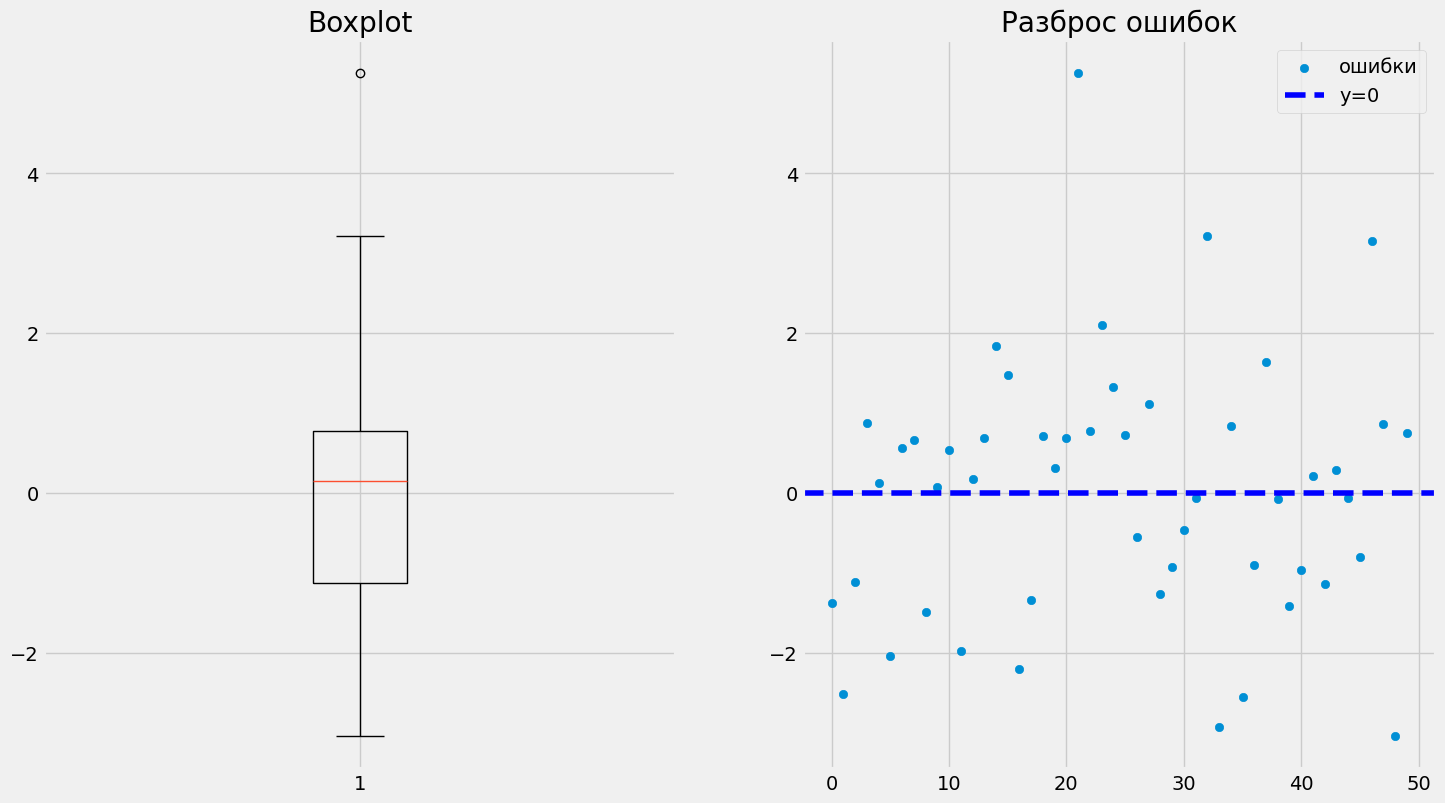

In [11]:
plt.style.use('fivethirtyeight')
_, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].boxplot(E)
ax[0].set_title('Boxplot')
ax[1].scatter(range(len(E)), E, label='ошибки')
ax[1].axhline(0, color='blue', linestyle='--', label='y=0')
ax[1].set_title('Разброс ошибок')
ax[1].legend()
q1 = np.percentile(E, 25)
q3 = np.percentile(E, 75)
print(f'q1 = {q1}, q3 = {q3}, IQR = {q3-q1}, e_min = {min(E)}, e_max = {max(E)}')
print(f'median = {np.median(E)}')
plt.show()

### h) Cross-validation

In [12]:
TSS = calc_TSS(Y)
CVSS = 0
for k in range(n):
    X_other = np.delete(X, k, axis=0)
    Y_other = np.delete(Y, k)
    beta_k = calc_beta(X_other, Y_other)
    Y_pred_k = calc_Y_pred(X[k, :], beta_k)
    CVSS += (Y[k] - Y_pred_k) ** 2
R2_cv = 1 - CVSS / TSS
print(f'CVSS = {CVSS:.3f}')
print(f'R^2_cv = {R2_cv:.3f}')


CVSS = 166.042
R^2_cv = 0.521


### i) Проверка адекватности регрессии

In [13]:
m = 5
x_point = np.array([1, 0, 0, 0, 0, 0])
y_points = st.norm(loc = 2 + 3*x_point[1] - 2*x_point[2] + x_point[3] + x_point[4] - x_point[5], scale = 1.5).rvs(m)

S2 = np.var(y_points, ddof=1)
delt_adeq = RSS / ((n - p) * S2)
p_val_adeq = 1 - st.f.cdf(delt_adeq, dfn=(n - p), dfd=(m - 1))

print(f'Статистика критерия delta = {delt_adeq:.3f}')
print(f'p_value = {p_val_adeq:.3f}, ', 'Модель не адекватна' if p_val_adeq < alpha else 'Модель адекватна')

Статистика критерия delta = 0.865
p_value = 0.657,  Модель адекватна


### j) Сравнение регрессий + повторение пунктов b) и c) на короткой регрессии



In [16]:
X_short = np.delete(X, 4, axis=1)
n_short, p_short = X_short.shape
beta_short = calc_beta(X_short, Y)
Y_pred_short = calc_Y_pred(X_short, beta_short)
RSS_short = calc_RSS(Y, Y_pred_short)
R2_short = calc_R2(Y, Y_pred_short)
F_inv_short = calc_F_inv(X_short)
print('Уравнение сокращённой регрессии (без x4):')
print(f'y = {beta_short[0]:.3f} + {beta_short[1]:.3f}*x1 + {beta_short[2]:.3f}*x2 + {beta_short[3]:.3f}*x3 + {beta_short[4]:.3f}*x5 + e')
print('\nПроверим значимость коэффициентов:')
feature_names = ['константа', 'x_1', 'x_2', 'x_3', 'x_5']
for i in range(p_short):
    t_i = abs(beta_short[i]) * np.sqrt(n_short - p_short) / np.sqrt(F_inv_short[i, i] * RSS_short)
    p_value_i = 2 * (1 - st.t.cdf(t_i, df=(n_short - p_short)))
    print(f'Коэффициент при {feature_names[i]}: статистика критерия = {t_i:.3f}, p_value = {p_value_i:.3f}, ', 'Коэффициент значим' if p_value_i < alpha else 'Коэффициент не значим')
print(f'Коэффициент детерминации R^2: {R2_short:.3f}')
delt_F = R2_short * (n_short - p_short) / ((1 - R2_short) * (p_short - 1))
p_value_F = 1 - st.f.cdf(delt_F, dfn=(p_short - 1), dfd=(n_short - p_short))
print(f'Статистика критерия F = {delt_F:.3f}, p_value = {p_value_F:.3f}, ', 'Коэффициент детерминации значим' if p_value_F < alpha else 'Коэффициент детерминации не значим')
print('\nСравнение регрессий:')
RSS1 = calc_RSS(Y, Y_pred)
RSS0 = RSS_short
p1, p0 = 6, 5
delta = (RSS0 - RSS1)*(n-p1)/(RSS1*(p1-p0))
p_val = 1 - st.f.cdf(delta, dfn=(p1-p0), dfd=(n-p1))
print(f'Статистика критерия = {delta:.3f}, p_value = {p_val:.3f}, ', 'Усложнение регрессии значимо' if p_val < alpha else 'Усложнение регрессии не значимо')



Уравнение сокращённой регрессии (без x4):
y = 2.071 + 2.749*x1 + -2.072*x2 + 0.976*x3 + -1.039*x5 + e

Проверим значимость коэффициентов:
Коэффициент при константа: статистика критерия = 8.172, p_value = 0.000,  Коэффициент значим
Коэффициент при x_1: статистика критерия = 6.138, p_value = 0.000,  Коэффициент значим
Коэффициент при x_2: статистика критерия = 4.526, p_value = 0.000,  Коэффициент значим
Коэффициент при x_3: статистика критерия = 2.180, p_value = 0.035,  Коэффициент значим
Коэффициент при x_5: статистика критерия = 2.376, p_value = 0.022,  Коэффициент значим
Коэффициент детерминации R^2: 0.597
Статистика критерия F = 16.642, p_value = 0.000,  Коэффициент детерминации значим

Сравнение регрессий:
Статистика критерия = 3.501, p_value = 0.068,  Усложнение регрессии не значимо


### k) Сравнение двух регрессий Bootstrap'ом


In [15]:
XY = np.hstack((X, Y.reshape(-1, 1)))
N_bs = 1000
h_wave = RSS_short - RSS

def bootstrap(N, data):
    deltas = []
    for _ in range(N):
        sample = data[np.random.choice(data.shape[0], size=data.shape[0], replace=True)]
        X_bs = sample[:, :-1]
        Y_bs = sample[:, -1]

        beta_full_bs = calc_beta(X_bs, Y_bs)
        RSS_full_bs = calc_RSS(Y_bs, calc_Y_pred(X_bs, beta_full_bs))

        X_bs_short = np.delete(X_bs, 4, axis=1)
        beta_short_bs = calc_beta(X_bs_short, Y_bs)
        RSS_short_bs = calc_RSS(Y_bs, calc_Y_pred(X_bs_short, beta_short_bs))

        h_star = RSS_short_bs - RSS_full_bs
        deltas.append(h_star - h_wave)
    return np.sort(np.array(deltas))

deltas = bootstrap(N_bs, XY)
ci_left  = h_wave - deltas[N_bs - 1]
ci_right = h_wave - deltas[int(0.05 * N_bs)]

print(f'Доверительный интервал для h: [{ci_left:.3f}, {ci_right:.3f}]')
print('Т.к. ноль входит в доверительный интервал, удаление переменной не оправдано (различие незначимо)'
      if ci_left < 0 < ci_right else 'Ноль не входит в доверительный интервал, удаление переменной оправдано (различие значимо)')

Доверительный интервал для h: [-48.318, 20.250]
Т.к. ноль входит в доверительный интервал, удаление переменной не оправдано (различие незначимо)
